In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score 

from sklearn.preprocessing import StandardScaler



In [212]:
# 1. Đọc và làm sạch dữ liệu
df = pd.read_csv("../trace_driven_simulation/data/simulation_data_198.csv")
TAU_SLO = 200
df_clean = df[df['response_time'] <= TAU_SLO].copy()
df_clean['slo_threshold'] = TAU_SLO

# Features: requests, SLO_threshold | Label: vms_count
X = df_clean[['requests', 'slo_threshold']]
y = df_clean['vms_count']

In [213]:
# 2. Chia dữ liệu (Random shuffle để bao phủ dải tải)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [214]:
X_train

,requests,slo_threshold
151,35530,200
89,21270,200
34,8620,200
169,39670,200
187,43810,200
...,...,...
91,21730,200
136,32080,200
18,4940,200
118,27940,200


In [215]:
# 3. Định nghĩa các mô hình
models = {
    "EN": ElasticNet(),
    "LR": LinearRegression(),
    "PR": make_pipeline(PolynomialFeatures(), LinearRegression()),
    "DTR": DecisionTreeRegressor(),
    "RDF": RandomForestRegressor()
}

In [216]:
# 4. Huấn luyện và đánh giá
mse_results, r2_results = {}, {}
print(f"{'Mô hình':<10} |{'MSE':<10} |  {'RMSE':<10} | {'R^2':<8} | {'NMSE'}")
print("-" * 45)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    mse_results[name] = mse
    r2_results[name] = r2

# Tính Normalized MSE sau khi đã có toàn bộ kết quả MSE
max_mse = max(mse_results.values())
norm_mse_results = {k: v / max_mse for k, v in mse_results.items()}

# In bảng kết quả
for name in models.keys():
    print(f"{name:<10} | {mse_results[name]:.6f} VM    |{np.sqrt(mse_results[name]):.6f} VM    | {r2_results[name]:.6f}   | {norm_mse_results[name]:.6f}")

Mô hình    |MSE        |  RMSE       | R^2      | NMSE
---------------------------------------------
EN         | 0.056732 VM    |0.238184 VM    | 0.999646   | 0.968457
LR         | 0.056732 VM    |0.238185 VM    | 0.999646   | 0.968462
PR         | 0.058579 VM    |0.242032 VM    | 0.999635   | 1.000000
DTR        | 0.032258 VM    |0.179605 VM    | 0.999799   | 0.550672
RDF        | 0.056974 VM    |0.238693 VM    | 0.999645   | 0.972596


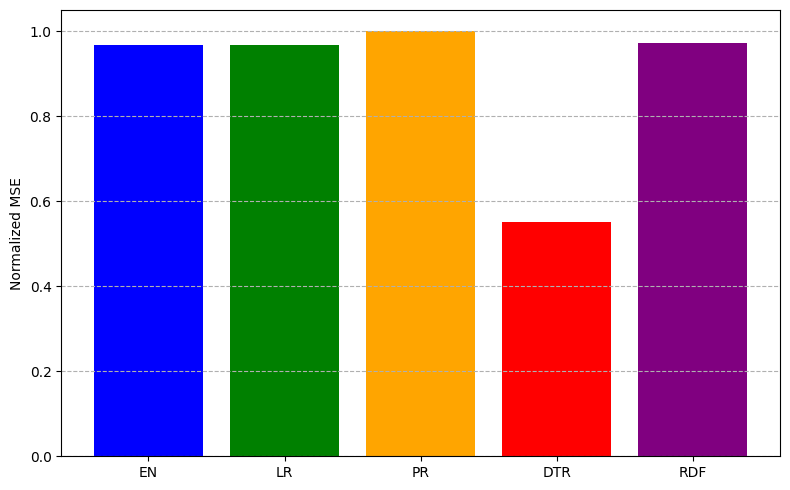


Mô hình tốt nhất (theo MSE): DTR


In [217]:
# 5. Vẽ đồ thị (Chỉ vẽ Normalized MSE)
plt.figure(figsize=(8, 5))

# Đồ thị Normalized MSE
plt.bar(norm_mse_results.keys(), norm_mse_results.values(), color=['blue', 'green', 'orange', 'red', 'purple'])
# plt.title('Prediction error (Normalized MSE)')
plt.ylabel('Normalized MSE')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

print(f"\nMô hình tốt nhất (theo MSE): {min(norm_mse_results, key=norm_mse_results.get)}")